# Data Exploration — SKAB Dataset

The SKAB (Skoltech Anomaly Benchmark) is a real industrial benchmark collected from a hydraulic testbed at the Skolkovo Institute of Science and Technology. It contains multivariate time series from 8 physical sensors with timestep-level anomaly labels, making it suitable for evaluating anomaly detection methods on gradual normal-to-anomaly transitions.

In [1]:
# Setup — run only once
import subprocess
subprocess.run(["git", "clone", "https://github.com/waico/SKAB"])

fatal: destination path 'SKAB' already exists and is not an empty directory.


CompletedProcess(args=['git', 'clone', 'https://github.com/waico/SKAB'], returncode=128)

## Normal data

We load the  file to inspect the available features and dataset dimensions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = "SKAB/data"

# Load normal data
df_normal = pd.read_csv(os.path.join(DATA_PATH, "anomaly-free/anomaly-free.csv"), sep=";")
print(df_normal.shape)
print(df_normal.head())

(9405, 9)
              datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0  2020-02-08 13:30:47           0.202394           0.275154  2.16975   
1  2020-02-08 13:30:48           0.203153           0.277857  2.07999   
2  2020-02-08 13:30:50           0.202054           0.275790  2.52577   
3  2020-02-08 13:30:51           0.203595           0.278101  2.49742   
4  2020-02-08 13:30:52           0.201889           0.276363  2.29194   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
0  0.382638      90.6454       26.8508  238.852              122.664  
1 -0.273216      90.7978       26.8639  227.943              122.338  
2  0.382638      90.7730       26.8603  223.486              121.338  
3  0.054711      90.8424       26.8616  244.904              121.664  
4  0.710565      90.6664       26.8603  239.196              122.000  


## Anomalous files

Anomalous files have two additional columns: `anomaly` (0/1) marks whether a timestep is anomalous, and `changepoint` (0/1) marks the onset of the change. This allows precise measurement of detection delay.

In [3]:
# Load an anomalous file
df_anom = pd.read_csv(os.path.join(DATA_PATH, "valve1/1.csv"), sep=";")
print(df_anom.shape)
print(df_anom.columns.tolist())
print(df_anom["anomaly"].value_counts())

(1145, 11)
['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
anomaly
0.0    743
1.0    402
Name: count, dtype: int64


## Feature visualization during an anomaly

The 8 features of `valve1/1.csv` with anomalous timesteps highlighted in red. Features such as Temperature and Volume Flow RateRMS show gradual changes in the anomalous zone, physically interpretable as the effect of progressive valve closure.

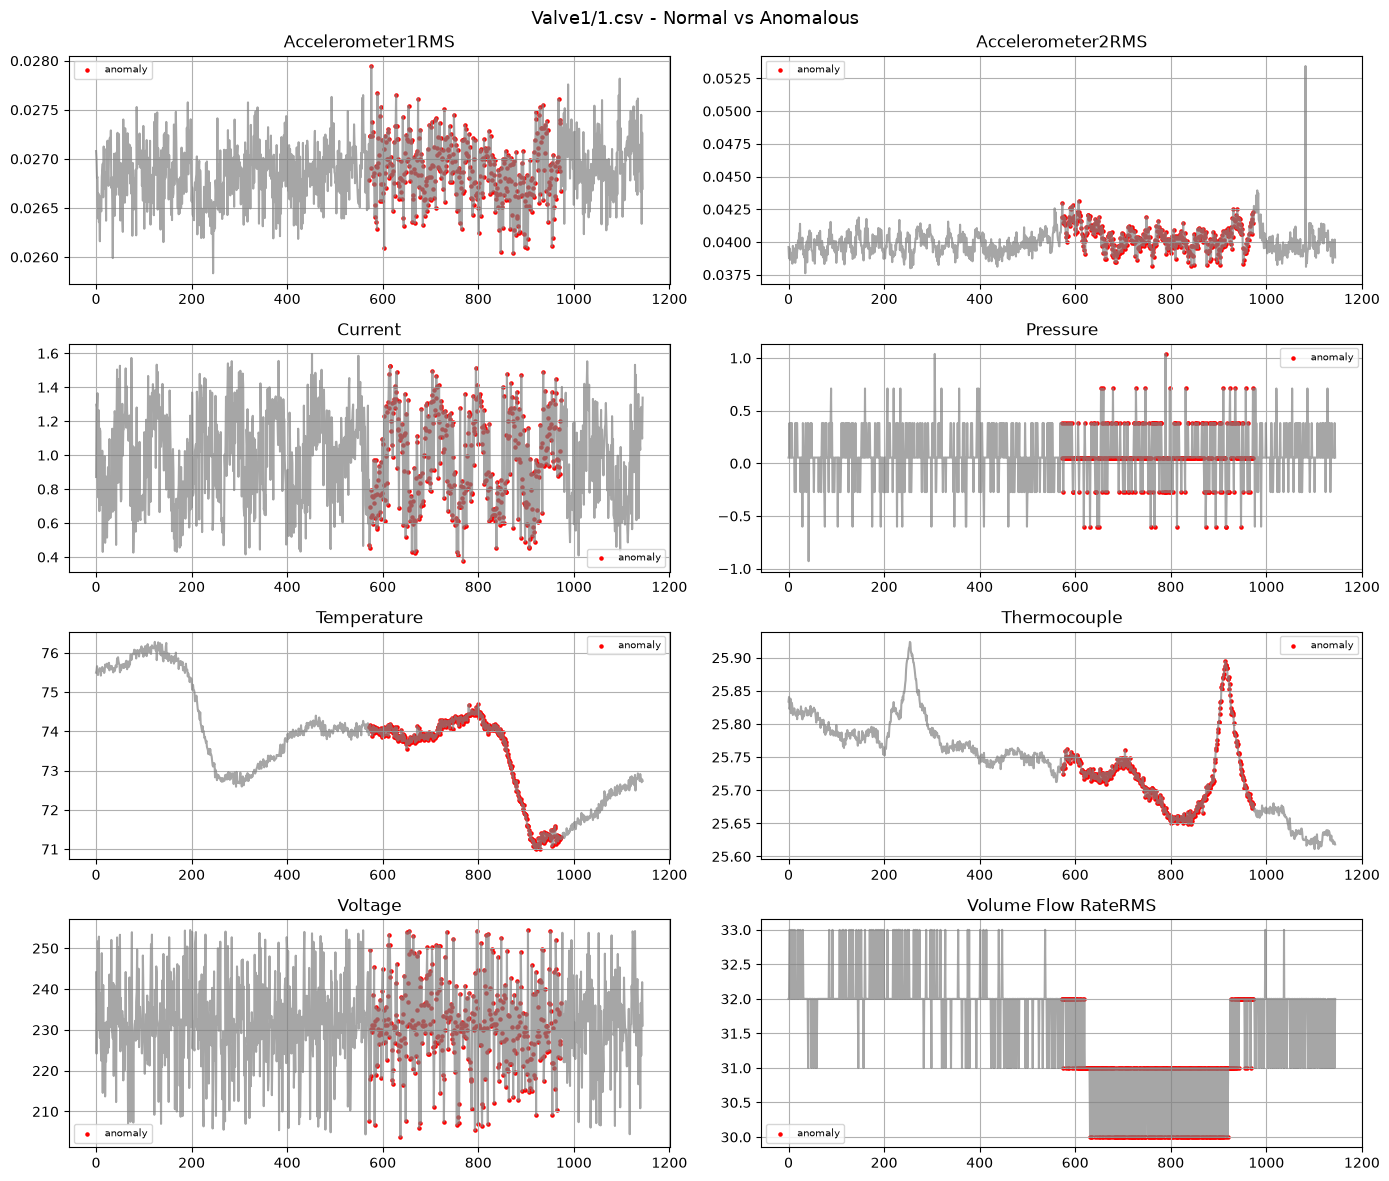

In [4]:
features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].plot(df_anom[feat], color="gray", alpha=0.7)
    # Highlight anomalous timesteps in red
    anomaly_idx = df_anom[df_anom["anomaly"] == 1].index
    axes[i].scatter(anomaly_idx, df_anom.loc[anomaly_idx, feat], 
                   color="red", s=5, label="anomaly")
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7)
    axes[i].grid(True)

plt.suptitle("Valve1/1.csv - Normal vs Anomalous", fontsize=13)
plt.tight_layout()
plt.show()